In [6]:
import xarray as xr
import rioxarray as rioxr

import geopandas as geopd
import pandas as pd

import numpy as np

import os
import pathlib

from parallelbar import progress_map

import matplotlib.pyplot as plt
plt.rcParams["figure.dpi"]  = 300
plt.style.use('dark_background')

# This script visualizes NetCDF data and calculates daily mean values for given watersheds.
# It reads NetCDF data, processes it, and generates plots to visualize the data.

In [7]:
# Path to the source NetCDF file
src_path = '/path/to/1985-06-potential_evaporation.nc'
with rioxr.open_rasterio(src_path, mask_and_scale=True) as data_array:
    data = data_array.copy()
    data = data.rio.write_crs("epsg:4326")

In [8]:
# Extract hourly data for the first 24 hours
counter = 0
hours = []
for time_step in data.valid_time:
    time = time_step.item()
    one_step_data = data.sel({'valid_time':time})
    hours.append(one_step_data)
    counter += 1
    if counter == 24:
        break

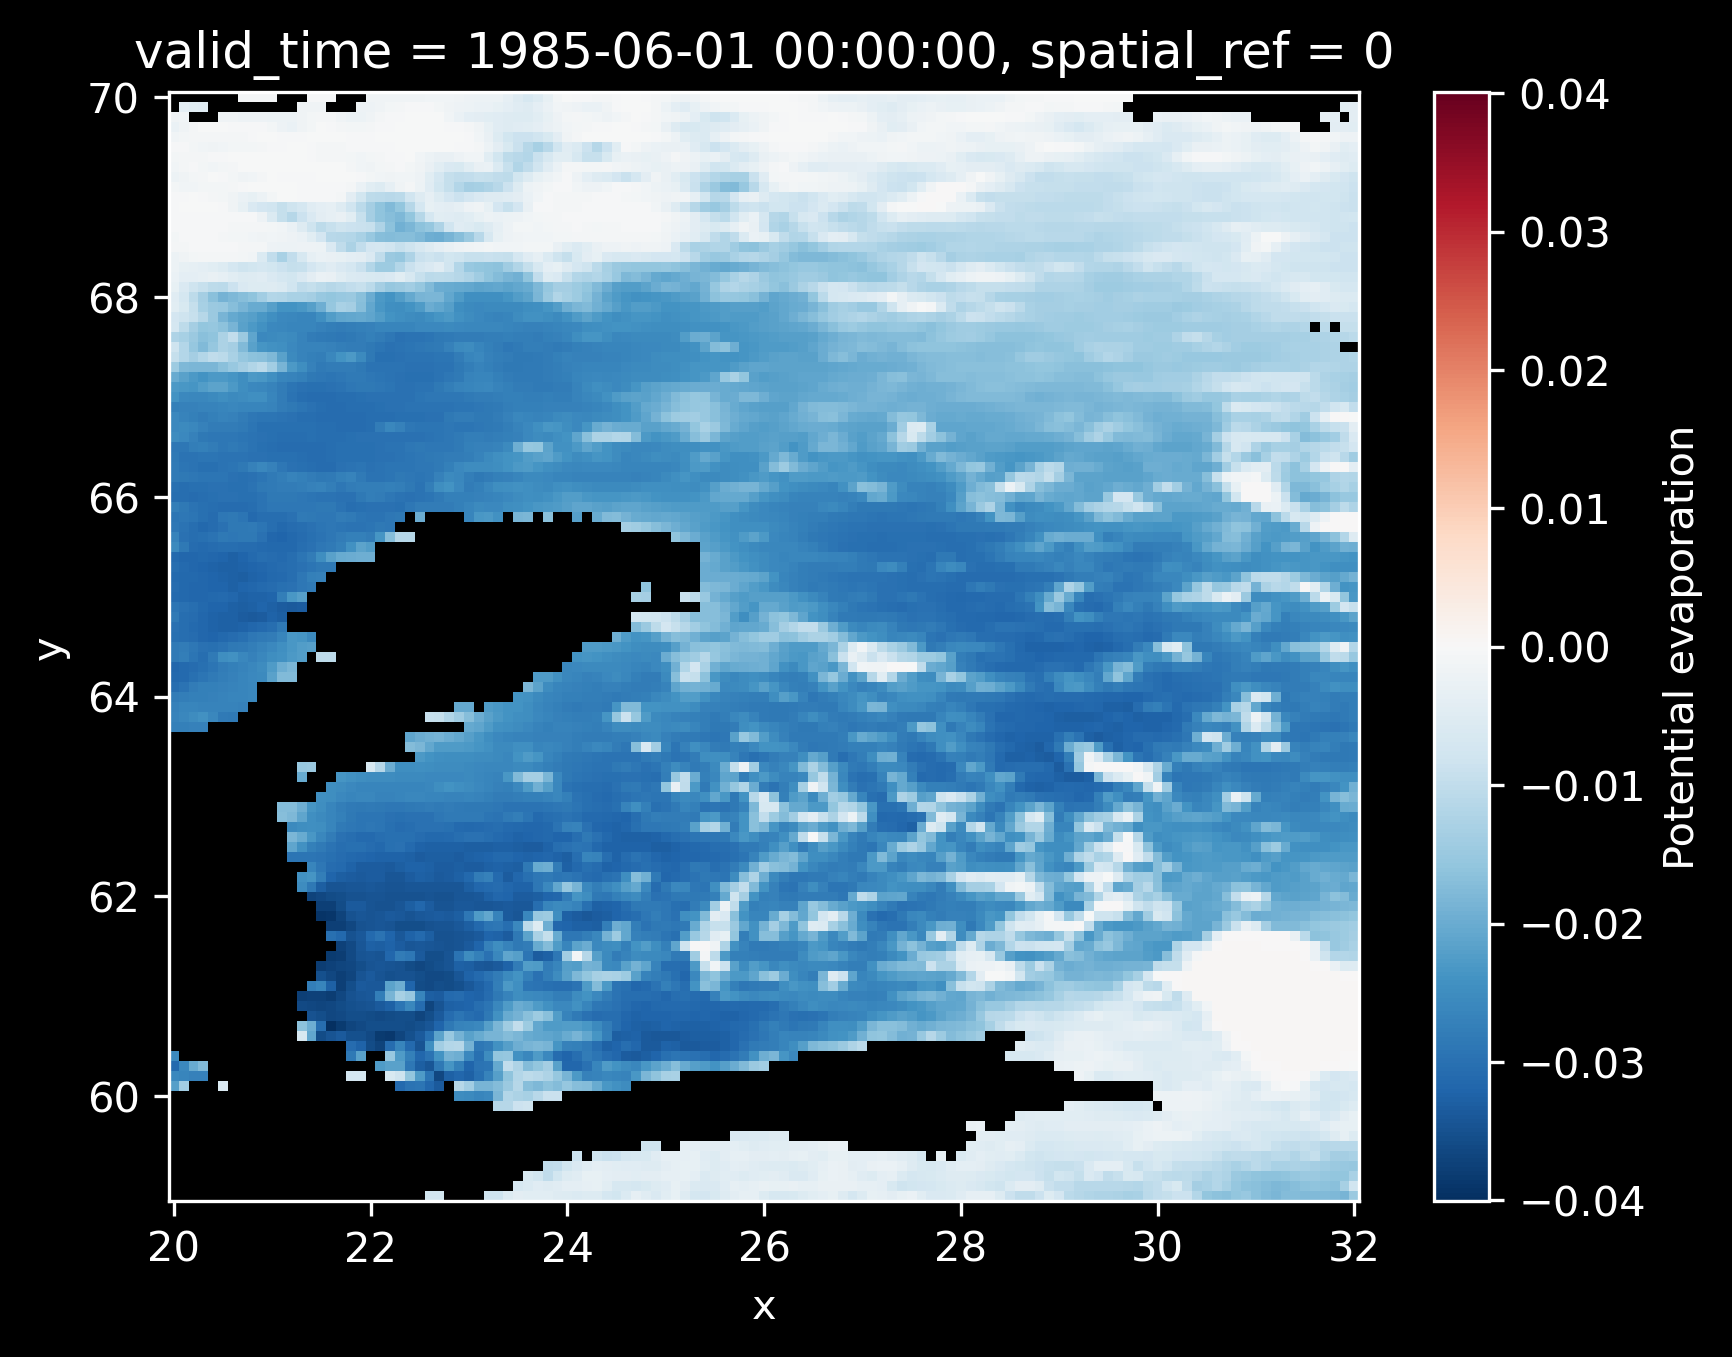

In [9]:
# Plot the data for specific hours
hours[0].plot(cbar_kwargs={'label': one_step_data.long_name})
#hours[23].plot(cbar_kwargs={'label': one_step_data.long_name})
#hours[6].plot(cbar_kwargs={'label': one_step_data.long_name})
#hours[12].plot(cbar_kwargs={'label': one_step_data.long_name})
#hours[18].plot(cbar_kwargs={'label': one_step_data.long_name})